<a href="https://colab.research.google.com/github/Shizukem/cu-i-k-/blob/main/b%C3%A0i_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

T    = 10                          # 2026-2035, t = 0..9
YEARS = list(range(2026, 2036))

# Hàm sản xuất Cobb-Douglas
ALPHA  = 0.33   # co giãn vốn vật chất K
BETA   = 0.42   # co giãn lao động L
GAMMA  = 0.10   # co giãn số hóa D
DELTA  = 0.08   # co giãn AI
THETA  = 0.07   # co giãn nhân lực số H

# Khấu hao
dK   = 0.05    # khấu hao vốn vật chất
dD   = 0.12    # khấu hao hạ tầng số
dAI  = 0.15    # khấu hao vốn AI

# Vốn nhân lực
theta_H = 0.80   # hiệu quả chuyển hóa I_H → H
mu      = 0.02   # chảy máu chất xám (suy giảm H)

# TFP nội sinh — hiệu chỉnh theo đơn vị đề bài
# D[%], AI[nghìn DN], H[%] → phi nhỏ để tránh A bùng nổ
phi1 = 0.001    # tác động D → A
phi2 = 0.0001   # tác động AI → A
phi3 = 0.0005   # tác động H → A
MAX_A_GROWTH = 1.05   # TFP tối đa tăng 5%/năm

# Chiết khấu
rho  = 0.97

# Điều kiện ban đầu 2026 (từ Bài 1)
K0   = 27_500.0   # nghìn tỷ VND
L0   = 53.9       # triệu LĐ (tăng ~0.6%/năm)
D0   = 20.3       # % GDP
AI0  = 86.0       # nghìn DN số
H0   = 30.0       # % LĐ qua đào tạo
A0   = 1.5        # TFP hiệu chỉnh từ Bài 1

# Lao động tăng 0.6%/năm
L_series = np.array([L0 * (1 + 0.006)**t for t in range(T)])

# GDP khởi đầu
Y0_init = A0 * K0**ALPHA * L0**BETA * D0**GAMMA * AI0**DELTA * H0**THETA
print(f'GDP khởi đầu Y_2026 = {Y0_init:,.1f} nghìn tỷ VND')

GDP khởi đầu Y_2026 = 571.8 nghìn tỷ VND


In [2]:
def simulate(params, shock_year=None, shock_pct=0.0):
    """
    Chạy mô phỏng T năm từ điều kiện đầu K0,D0,AI0,H0,A0.

    params: vector 5T = [IK(0..T-1), ID(0..T-1), IAI(0..T-1),
                         IH(0..T-1), C(0..T-1)]
    shock_year : năm xảy ra cú sốc (vd 2028 → t=2)
    shock_pct  : % giảm Y (vd 0.08 = -8%)

    Trả về: welfare, Ks, Ds, AIs, Hs, As, Ys, Cs
    """
    IK  = params[0*T : 1*T]
    ID  = params[1*T : 2*T]
    IAI = params[2*T : 3*T]
    IH  = params[3*T : 4*T]
    C   = params[4*T : 5*T]

    K, D, AI, H, A = K0, D0, AI0, H0, A0
    welfare = 0.0
    Ks  = [K0];  Ds  = [D0];  AIs = [AI0]
    Hs  = [H0];  As  = [A0];  Ys  = []

    for t in range(T):
        L = L_series[t]
        Y = (A * max(K,  1.0)**ALPHA
               * L**BETA
               * max(D,  0.1)**GAMMA
               * max(AI, 0.1)**DELTA
               * max(H,  0.1)**THETA)

        # Áp dụng cú sốc
        if shock_year is not None and t == (shock_year - 2026):
            Y = Y * (1.0 - shock_pct)

        Ys.append(Y)
        welfare += rho**t * np.log(max(C[t], 1e-6))

        # Cập nhật trạng thái
        K  = (1 - dK)  * K  + IK[t]
        D  = (1 - dD)  * D  + ID[t]
        AI = (1 - dAI) * AI + IAI[t]
        H  = max(H + theta_H * IH[t] - mu * H, 0.1)
        A_factor = 1.0 + phi1*max(D, 0) + phi2*max(AI, 0) + phi3*max(H, 0)
        A  = A * min(A_factor, MAX_A_GROWTH)

        Ks.append(K);  Ds.append(D);  AIs.append(AI)
        Hs.append(H);  As.append(A)

    return (welfare,
            np.array(Ks), np.array(Ds), np.array(AIs),
            np.array(Hs),  np.array(As),  np.array(Ys),
            np.array(C))


def neg_welfare(params, shock_year=None, shock_pct=0.0):
    w, *_ = simulate(params, shock_year, shock_pct)
    return -w


def con_budget(params, shock_year=None, shock_pct=0.0):
    """C[t] + I[t] <= Y[t] → trả về Y[t]-C[t]-ΣI[t] >= 0."""
    _, _, _, _, _, _, Ys, _ = simulate(params, shock_year, shock_pct)
    IK=params[0:T]; ID=params[T:2*T]; IAI=params[2*T:3*T]
    IH=params[3*T:4*T]; C=params[4*T:5*T]
    return np.array([
        Ys[t] - C[t] - IK[t] - ID[t] - IAI[t] - IH[t]
        for t in range(T)
    ])

In [3]:
from scipy.optimize import minimize

def optimize(shock_year=None, shock_pct=0.0,
             strategy='optimal', label='Tối ưu'):
    """
    Giải bài toán tối ưu bằng SLSQP.
    strategy: 'optimal'   → tối ưu tự do
              'equal'     → trải đều (mỗi hạng mục = hằng số)
              'frontload' → 60% đầu tư vào 3 năm đầu
    """
    # ── Điểm khởi đầu ──────────────────────────────────────
    x0 = np.zeros(5 * T)
    for t in range(T):
        y_t = Y0_init * 1.07**t
        x0[0*T+t] = y_t * 0.12   # IK
        x0[1*T+t] = y_t * 0.05   # ID
        x0[2*T+t] = y_t * 0.05   # IAI
        x0[3*T+t] = y_t * 0.05   # IH
        x0[4*T+t] = y_t * 0.73   # C

    bounds = [(1.0, None)] * (5 * T)

    if strategy == 'optimal':
        # ── Tối ưu tự do ───────────────────────────────────
        res = minimize(
            neg_welfare, x0,
            args=(shock_year, shock_pct),
            method='SLSQP',
            bounds=bounds,
            constraints=[{
                'type': 'ineq',
                'fun':  con_budget,
                'args': (shock_year, shock_pct),
            }],
            options={'maxiter': 5000, 'ftol': 1e-10, 'disp': False},
        )
        params_out = res.x
        status = res.status

    elif strategy == 'equal':
        # ── Đầu tư trải đều ────────────────────────────────
        # Phân bổ cố định: 12% K, 5% D, 5% AI, 5% H, 73% C của Y
        params_out = x0.copy()   # đã thiết lập tỷ lệ bằng nhau
        status = 0

    elif strategy == 'frontload':
        # ── Front-load ─────────────────────────────────────
        # 3 năm đầu: tăng tỷ lệ đầu tư lên 45%, giảm C
        # 7 năm sau: giảm tỷ lệ đầu tư xuống 20%
        params_out = x0.copy()
        for t in range(T):
            y_t = Y0_init * 1.07**t
            if t < 3:
                params_out[0*T+t] = y_t * 0.18
                params_out[1*T+t] = y_t * 0.08
                params_out[2*T+t] = y_t * 0.08
                params_out[3*T+t] = y_t * 0.08
                params_out[4*T+t] = y_t * 0.58
            else:
                params_out[0*T+t] = y_t * 0.07
                params_out[1*T+t] = y_t * 0.03
                params_out[2*T+t] = y_t * 0.03
                params_out[3*T+t] = y_t * 0.03
                params_out[4*T+t] = y_t * 0.84
        status = 0

    # ── Lấy kết quả ────────────────────────────────────────
    w, Ks, Ds, AIs, Hs, As, Ys, Cs = simulate(
        params_out, shock_year, shock_pct)

    IK  = params_out[0*T:1*T]
    ID  = params_out[1*T:2*T]
    IAI = params_out[2*T:3*T]
    IH  = params_out[3*T:4*T]

    return {
        'label':   label,
        'welfare': w,
        'status':  status,
        'params':  params_out,
        'IK': IK, 'ID': ID, 'IAI': IAI, 'IH': IH,
        'Ks': Ks, 'Ds': Ds, 'AIs': AIs,
        'Hs': Hs, 'As': As, 'Ys': Ys, 'Cs': Cs,
    }

In [4]:
print('=' * 68)
print('  BÀI 8 — TỐI ƯU ĐỘNG PHÂN BỔ LIÊN THỜI GIAN 2026-2035')
print('  max Σ ρ^t · ln(C_t)   |   SLSQP   |   T = 10 năm')
print('=' * 68)

print('\n[ Câu 8.3.1 ] Tối ưu hóa SLSQP (Cách B)')
print('-' * 60)

res_opt = optimize(strategy='optimal', label='Tối ưu SLSQP')
W_opt   = res_opt['welfare']
st_msg  = 'Thành công ✓' if res_opt['status'] == 0 else f'Cảnh báo (status={res_opt["status"]})'

print(f'  Trạng thái  : {st_msg}')
print(f'  Welfare* W* = {W_opt:.4f}')
print(f'\n  Bảng quỹ đạo tối ưu 2026-2035:')
print(f"  {'Năm':>5} {'Y':>9} {'IK':>8} {'ID':>8} {'IAI':>7}"
      f" {'IH':>7} {'C':>9} {'K':>9} {'D':>7} {'H':>7} {'A':>7}")
print('  ' + '-' * 90)
for t in range(T):
    print(f"  {YEARS[t]:>5} "
          f"{res_opt['Ys'][t]:>9.1f} "
          f"{res_opt['IK'][t]:>8.1f} "
          f"{res_opt['ID'][t]:>8.1f} "
          f"{res_opt['IAI'][t]:>7.1f} "
          f"{res_opt['IH'][t]:>7.1f} "
          f"{res_opt['Cs'][t]:>9.1f} "
          f"{res_opt['Ks'][t]:>9.1f} "
          f"{res_opt['Ds'][t]:>7.2f} "
          f"{res_opt['Hs'][t]:>7.2f} "
          f"{res_opt['As'][t]:>7.4f}")

# ── Tỷ lệ đầu tư so với Y ──────────────────────────────────
print(f'\n  Tỷ lệ đầu tư / Y (%) và tỷ lệ C/Y:')
print(f"  {'Năm':>5} {'IK/Y%':>7} {'ID/Y%':>7} {'IAI/Y%':>7} {'IH/Y%':>7} {'C/Y%':>7} {'Tổng ĐT%':>10}")
for t in range(T):
    Y = res_opt['Ys'][t]
    pK  = res_opt['IK'][t]  / Y * 100
    pD  = res_opt['ID'][t]  / Y * 100
    pAI = res_opt['IAI'][t] / Y * 100
    pH  = res_opt['IH'][t]  / Y * 100
    pC  = res_opt['Cs'][t]  / Y * 100
    print(f"  {YEARS[t]:>5} {pK:>7.1f} {pD:>7.1f} {pAI:>7.1f} {pH:>7.1f} {pC:>7.1f} {pK+pD+pAI+pH:>10.1f}")

# ── Nhận xét front/back-loaded ──────────────────────────────
avg_inv_early = sum(
    (res_opt['IK'][t]+res_opt['ID'][t]+res_opt['IAI'][t]+res_opt['IH'][t])
    / res_opt['Ys'][t] for t in range(3)) / 3 * 100
avg_inv_late = sum(
    (res_opt['IK'][t]+res_opt['ID'][t]+res_opt['IAI'][t]+res_opt['IH'][t])
    / res_opt['Ys'][t] for t in range(3, T)) / (T-3) * 100
print(f'\n  Tỷ lệ đầu tư TB 3 năm đầu: {avg_inv_early:.1f}%')
print(f'  Tỷ lệ đầu tư TB 7 năm sau: {avg_inv_late:.1f}%')
front_back = 'FRONT-LOADED' if avg_inv_early > avg_inv_late else 'BACK-LOADED'
print(f'  → Quỹ đạo tối ưu: {front_back}')

  BÀI 8 — TỐI ƯU ĐỘNG PHÂN BỔ LIÊN THỜI GIAN 2026-2035
  max Σ ρ^t · ln(C_t)   |   SLSQP   |   T = 10 năm

[ Câu 8.3.1 ] Tối ưu hóa SLSQP (Cách B)
------------------------------------------------------------
  Trạng thái  : Thành công ✓
  Welfare* W* = 58.8274

  Bảng quỹ đạo tối ưu 2026-2035:
    Năm         Y       IK       ID     IAI      IH         C         K       D       H       A
  ------------------------------------------------------------------------------------------
   2026     571.8      1.0    111.6    25.6    72.1     361.6   27500.0   20.30   30.00  1.5000
   2027     775.9      1.0     96.9    73.9    85.4     518.7   26126.0  129.48   87.05  1.5750
   2028     910.9      1.0     94.4    72.9    82.4     660.3   24820.7  210.87  153.62  1.6538
   2029    1015.3      1.0     94.8    73.9    49.8     795.8   23580.7  279.98  216.43  1.7364
   2030    1099.7      1.0     94.9    74.7     1.0     928.1   22402.6  341.23  251.92  1.8233
   2031    1166.5      1.0     44.9 

In [5]:
print('\n[ Câu 8.3.3 ] Cú sốc năm 2028: Y giảm 8% (như bão Yagi 2024)')
print('-' * 60)

res_shock = optimize(shock_year=2028, shock_pct=0.08,
                     strategy='optimal', label='Cú sốc 2028')
W_shock   = res_shock['welfare']

print(f'  Welfare (có cú sốc) = {W_shock:.4f}')
print(f'  Welfare (không cú sốc) = {W_opt:.4f}')
print(f'  ΔWelfare = {W_shock - W_opt:.4f}  '
      f'({(W_shock-W_opt)/abs(W_opt)*100:.2f}%)')

print(f'\n  Điều chỉnh phân bổ sau cú sốc (so sánh t=2028,2029,2030):')
print(f"  {'Năm':>5} {'ΔIK':>8} {'ΔID':>8} {'ΔIAI':>8} {'ΔIH':>8} {'ΔC':>9}")
for t in [2, 3, 4]:   # 2028, 2029, 2030
    yr = YEARS[t]
    dik  = res_shock['IK'][t]  - res_opt['IK'][t]
    did  = res_shock['ID'][t]  - res_opt['ID'][t]
    diai = res_shock['IAI'][t] - res_opt['IAI'][t]
    dih  = res_shock['IH'][t]  - res_opt['IH'][t]
    dc   = res_shock['Cs'][t]  - res_opt['Cs'][t]
    print(f'  {yr:>5} {dik:>+8.1f} {did:>+8.1f} {diai:>+8.1f} '
          f'{dih:>+8.1f} {dc:>+9.1f}')


[ Câu 8.3.3 ] Cú sốc năm 2028: Y giảm 8% (như bão Yagi 2024)
------------------------------------------------------------
  Welfare (có cú sốc) = 58.7216
  Welfare (không cú sốc) = 58.8274
  ΔWelfare = -0.1059  (-0.18%)

  Điều chỉnh phân bổ sau cú sốc (so sánh t=2028,2029,2030):
    Năm      ΔIK      ΔID     ΔIAI      ΔIH        ΔC
   2028     +0.0    -14.7     -9.7    -23.0     -23.3
   2029     +0.0     -2.2     -1.6     +9.5     -19.3
   2030     +0.0     +3.0     +2.1     +0.0     -14.9


In [6]:
print('\n[ Câu 8.3.4 ] So sánh 3 chiến lược đầu tư')
print('-' * 60)

res_equal = optimize(strategy='equal',     label='Đầu tư trải đều')
res_front = optimize(strategy='frontload', label='Đầu tư front-load')

results_3 = [res_opt, res_front, res_equal]

print(f"  {'Chiến lược':<28} {'Welfare':>10} {'Y_2035':>12} {'K_2035':>12} {'H_2035':>10}")
print('  ' + '-' * 76)
for r in results_3:
    print(f"  {r['label']:<28} {r['welfare']:>10.4f} "
          f"{r['Ys'][-1]:>12.1f} "
          f"{r['Ks'][-1]:>12.1f} "
          f"{r['Hs'][-1]:>10.2f}")

best_label = max(results_3, key=lambda r: r['welfare'])['label']
print(f'\n  → Chiến lược tốt nhất về Welfare: {best_label}')

w_gain_front = (res_front['welfare'] - res_equal['welfare'])
w_gain_pct   = w_gain_front / abs(res_equal['welfare']) * 100
print(f'  → Front-load vs. Trải đều: ΔW = {w_gain_front:+.4f} ({w_gain_pct:+.2f}%)')


[ Câu 8.3.4 ] So sánh 3 chiến lược đầu tư
------------------------------------------------------------
  Chiến lược                      Welfare       Y_2035       K_2035     H_2035
  ----------------------------------------------------------------------------
  Tối ưu SLSQP                    58.8274       1244.6      16473.3     227.73
  Đầu tư front-load               55.4801       1200.8      17056.3     262.50
  Đầu tư trải đều                 55.3297       1275.2      17247.7     316.79

  → Chiến lược tốt nhất về Welfare: Tối ưu SLSQP
  → Front-load vs. Trải đều: ΔW = +0.1504 (+0.27%)


In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import os

# Define colors used in the plots (assuming these are constants)
C_Y = '#1f77b4' # Example color for Y (blue)
C_C = '#ff7f0e' # Example color for C (orange)
C_K = '#2ca02c' # Example color for K (green)
C_D = '#d62728' # Example color for D (red)
C_AI = '#9467bd' # Example color for AI (purple)
C_H = '#8c564b' # Example color for H (brown)
C_A = '#e377c2' # Example color for A (pink)
C_SH = '#17becf' # Example color for Shock (cyan)
C_PURP = '#6c3483' # Example color for specific purple if not using C_AI
C_MAIN = '#1a5276' # Main color if different from C_Y

print('\n  Đang vẽ biểu đồ chính...')

fig  = plt.figure(figsize=(20, 26))
fig.patch.set_facecolor('white')
gs   = GridSpec(3, 2, figure=fig, hspace=0.50, wspace=0.36)

yrs  = np.array(YEARS)          # 2026-2035
yrs1 = np.array(YEARS + [2036]) # trạng thái có t+1 điểm

# ── Panel 1: Quỹ đạo Y, C (nghìn tỷ VND) ────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(yrs, res_opt['Ys'], 'o-', color=C_Y,   lw=2.5, ms=7, label='GDP (Y)')
ax1.plot(yrs, res_opt['Cs'], 's--',color=C_C,   lw=2.5, ms=7, label='Tiêu dùng (C)')
ax1.fill_between(yrs, res_opt['Cs'], res_opt['Ys'],
                 alpha=0.12, color=C_K, label='Phần đầu tư (Y-C)')
ax1.set_title('Câu 8.3.2 — Quỹ đạo GDP và Tiêu dùng\n'
              '(Kịch bản tối ưu, đơn vị: nghìn tỷ VND)', pad=14)
ax1.set_ylabel('Nghìn tỷ VND')
ax1.set_xticks(yrs); ax1.set_xticklabels(yrs, rotation=25, fontsize=9.5)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))
ax1.legend(fontsize=10)

# ── Panel 2: Quỹ đạo K, D, AI, H (trục khác nhau) ───────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2_r = ax2.twinx()

lK,  = ax2.plot(yrs1, res_opt['Ks'], 'o-',  color=C_K,  lw=2.5, ms=6, label='K (nghìn tỷ, trái)')
lD,  = ax2_r.plot(yrs1, res_opt['Ds'], 's--', color=C_D,  lw=2.2, ms=6, label='D % GDP (phải)')
lAI, = ax2_r.plot(yrs1, res_opt['AIs'],'v-.', color=C_AI, lw=2.2, ms=6, label='AI nghìn DN (phải)')
lH,  = ax2_r.plot(yrs1, res_opt['Hs'], 'D:',  color=C_H,  lw=2.2, ms=6, label='H % LĐ (phải)')

ax2.set_ylabel('K (nghìn tỷ VND)', color=C_K)
ax2_r.set_ylabel('D (%), AI (nghìn DN), H (%)', color='gray')
ax2.tick_params(axis='y', labelcolor=C_K)
ax2_r.tick_params(axis='y', labelcolor='gray')
ax2.set_title('Câu 8.3.2 — Quỹ đạo vốn K, D, AI, H\n'
              '(Trục trái: K | Trục phải: D, AI, H)', pad=14)
ax2.set_xticks(yrs1[:-1]); ax2.set_xticklabels(yrs, rotation=25, fontsize=9.5)
lines = [lK, lD, lAI, lH]
labs  = [l.get_label() for l in lines]
ax2.legend(lines, labs, fontsize=8.5, loc='upper right')

# ── Panel 3: Quỹ đạo đầu tư (4 loại) ────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.stackplot(yrs,
              res_opt['IK'], res_opt['ID'],
              res_opt['IAI'], res_opt['IH'],
              labels=['I_K (Vốn VL)', 'I_D (Số hóa)',
                      'I_AI (AI)',    'I_H (Nhân lực)'],
              colors=[C_K, C_D, C_AI, C_H], alpha=0.82)
ax3.set_title('Câu 8.3.2 — Cơ cấu đầu tư theo hạng mục\n'
              '(Stacked area, đơn vị: nghìn tỷ VND)', pad=14)
ax3.set_ylabel('Đầu tư (nghìn tỷ VND)')
ax3.set_xticks(yrs); ax3.set_xticklabels(yrs, rotation=25, fontsize=9.5)
ax3.legend(fontsize=9, loc='upper left', ncol=2)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))

# ── Panel 4: TFP A_t và GDP Y_t ──────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4_r = ax4.twinx()
ax4.bar(yrs, res_opt['Ys'], color=C_Y, alpha=0.55, width=0.5,
        label='GDP Y (trái)')
ax4_r.plot(yrs1, res_opt['As'], 'o-', color=C_A, lw=2.5, ms=7,
           label='TFP A (phải)')
ax4.set_ylabel('GDP Y (nghìn tỷ VND)', color=C_Y)
ax4_r.set_ylabel('TFP A_t', color=C_A)
ax4.tick_params(axis='y', labelcolor=C_Y)
ax4_r.tick_params(axis='y', labelcolor=C_A)
ax4.set_title('Câu 8.3.2 — GDP và TFP theo thời gian\n'
              '(Cột: Y | Đường: TFP A_t)', pad=14)
ax4.set_xticks(yrs); ax4.set_xticklabels(yrs, rotation=25, fontsize=9.5)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))
lines4 = [mpatches.Patch(color=C_Y, alpha=0.6, label='GDP Y (trái)'),
          mpatches.Patch(color=C_A, label='TFP A (phải)')]
ax4.legend(handles=lines4, fontsize=9, loc='upper left')

# ── Panel 5: Cú sốc 2028 — so sánh Y và C ───────────────────────
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(yrs, res_opt['Ys'],   'o-',  color=C_Y,  lw=2.5, ms=7,
         label='Y  (không cú sốc)')
ax5.plot(yrs, res_shock['Ys'], 's--', color=C_SH, lw=2.5, ms=7,
         label='Y  (CÚ SỐC 2028 −8%)')
ax5.plot(yrs, res_opt['Cs'],   'v-',  color=C_C,  lw=2, ms=6,
         label='C  (không cú sốc)', alpha=0.7)
ax5.plot(yrs, res_shock['Cs'],'D--', color=C_PURP if False else '#6c3483',
         lw=2, ms=6, label='C  (có cú sốc)', alpha=0.7)

ax5.axvline(2028, color='red', ls=':', lw=2.0)
ax5.text(2028.05, res_opt['Ys'][2]*0.85, 'Cú sốc\n2028', color='red', fontsize=9.5)

ax5.set_title('Câu 8.3.3 — Tác động cú sốc Y giảm 8% năm 2028\n'
              f'ΔWelfare = {W_shock-W_opt:+.4f}  '
              f'({(W_shock-W_opt)/abs(W_opt)*100:+.2f}%)', pad=14)
ax5.set_ylabel('Nghìn tỷ VND')
ax5.set_xticks(yrs); ax5.set_xticklabels(yrs, rotation=25, fontsize=9.5)
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))
ax5.legend(fontsize=8.5, loc='upper left', ncol=2)

# ── Panel 6: So sánh 3 chiến lược — Welfare & Y_2035 ─────────────
ax6 = fig.add_subplot(gs[2, 1])
strat_labels = [r['label'] for r in results_3]
welfares     = [r['welfare'] for r in results_3]
Y_2035s      = [r['Ys'][-1] for r in results_3]
cols6 = [C_MAIN, C_SH, '#95a5a6'] # Using C_MAIN from definitions above

xp6 = np.arange(3)
w6  = 0.35
ax6_r = ax6.twinx()
b6a = ax6.bar(xp6 - w6/2, welfares, width=w6,
              color=[C_Y, C_D, C_AI], alpha=0.85,
              label='Welfare W (trái)')
b6b = ax6_r.bar(xp6 + w6/2, Y_2035s, width=w6,
                color=[C_K, C_H, '#95a5a6'], alpha=0.72,
                label='Y_2035 (phải)')

for bar, v in zip(b6a, welfares):
    ax6.text(bar.get_x()+bar.get_width()/2, v+0.1,
             f'{v:.2f}', ha='center', fontsize=9.5, fontweight='bold')
for bar, v in zip(b6b, Y_2035s):
    ax6_r.text(bar.get_x()+bar.get_width()/2, v+2,
               f'{v:,.0f}', ha='center', fontsize=9, color='#2c3e50')

ax6.set_xticks(xp6)
ax6.set_xticklabels(strat_labels, fontsize=9.5)
ax6.set_ylabel('Welfare W (trái)', color=C_Y)
ax6_r.set_ylabel('GDP năm 2035 — nghìn tỷ (phải)', color=C_K)
ax6.tick_params(axis='y', labelcolor=C_Y)
ax6_r.tick_params(axis='y', labelcolor=C_K)
ax6_r.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))
ax6.set_title('Câu 8.3.4 — So sánh 3 chiến lược đầu tư\n'
              'Welfare tổng và GDP 2035', pad=14)
lines6 = [mpatches.Patch(color=C_Y, alpha=0.85, label='Welfare (trái)'),
          mpatches.Patch(color=C_K, alpha=0.72, label='Y_2035 (phải)')]
ax6.legend(handles=lines6, fontsize=9, loc='upper right')

fig.suptitle(
    'BÀI 8 — TỐI ƯU ĐỘNG PHÂN BỔ LIÊN THỜI GIAN 2026-2035\n'
    'max Σ ρ^t·ln(C_t)   |   Hàm sản xuất Cobb-Douglas mở rộng   |   SLSQP',
    fontsize=14, fontweight='bold', y=0.999,
)

# Create the directory if it does not exist
os.makedirs('/mnt/user-data/outputs', exist_ok=True)

plt.savefig('/mnt/user-data/outputs/bai8_dynamic_chinh.png',
            bbox_inches='tight', dpi=150, facecolor='white')
plt.close(fig)
print('  [✓] bai8_dynamic_chinh.png — đã lưu')


  Đang vẽ biểu đồ chính...
  [✓] bai8_dynamic_chinh.png — đã lưu


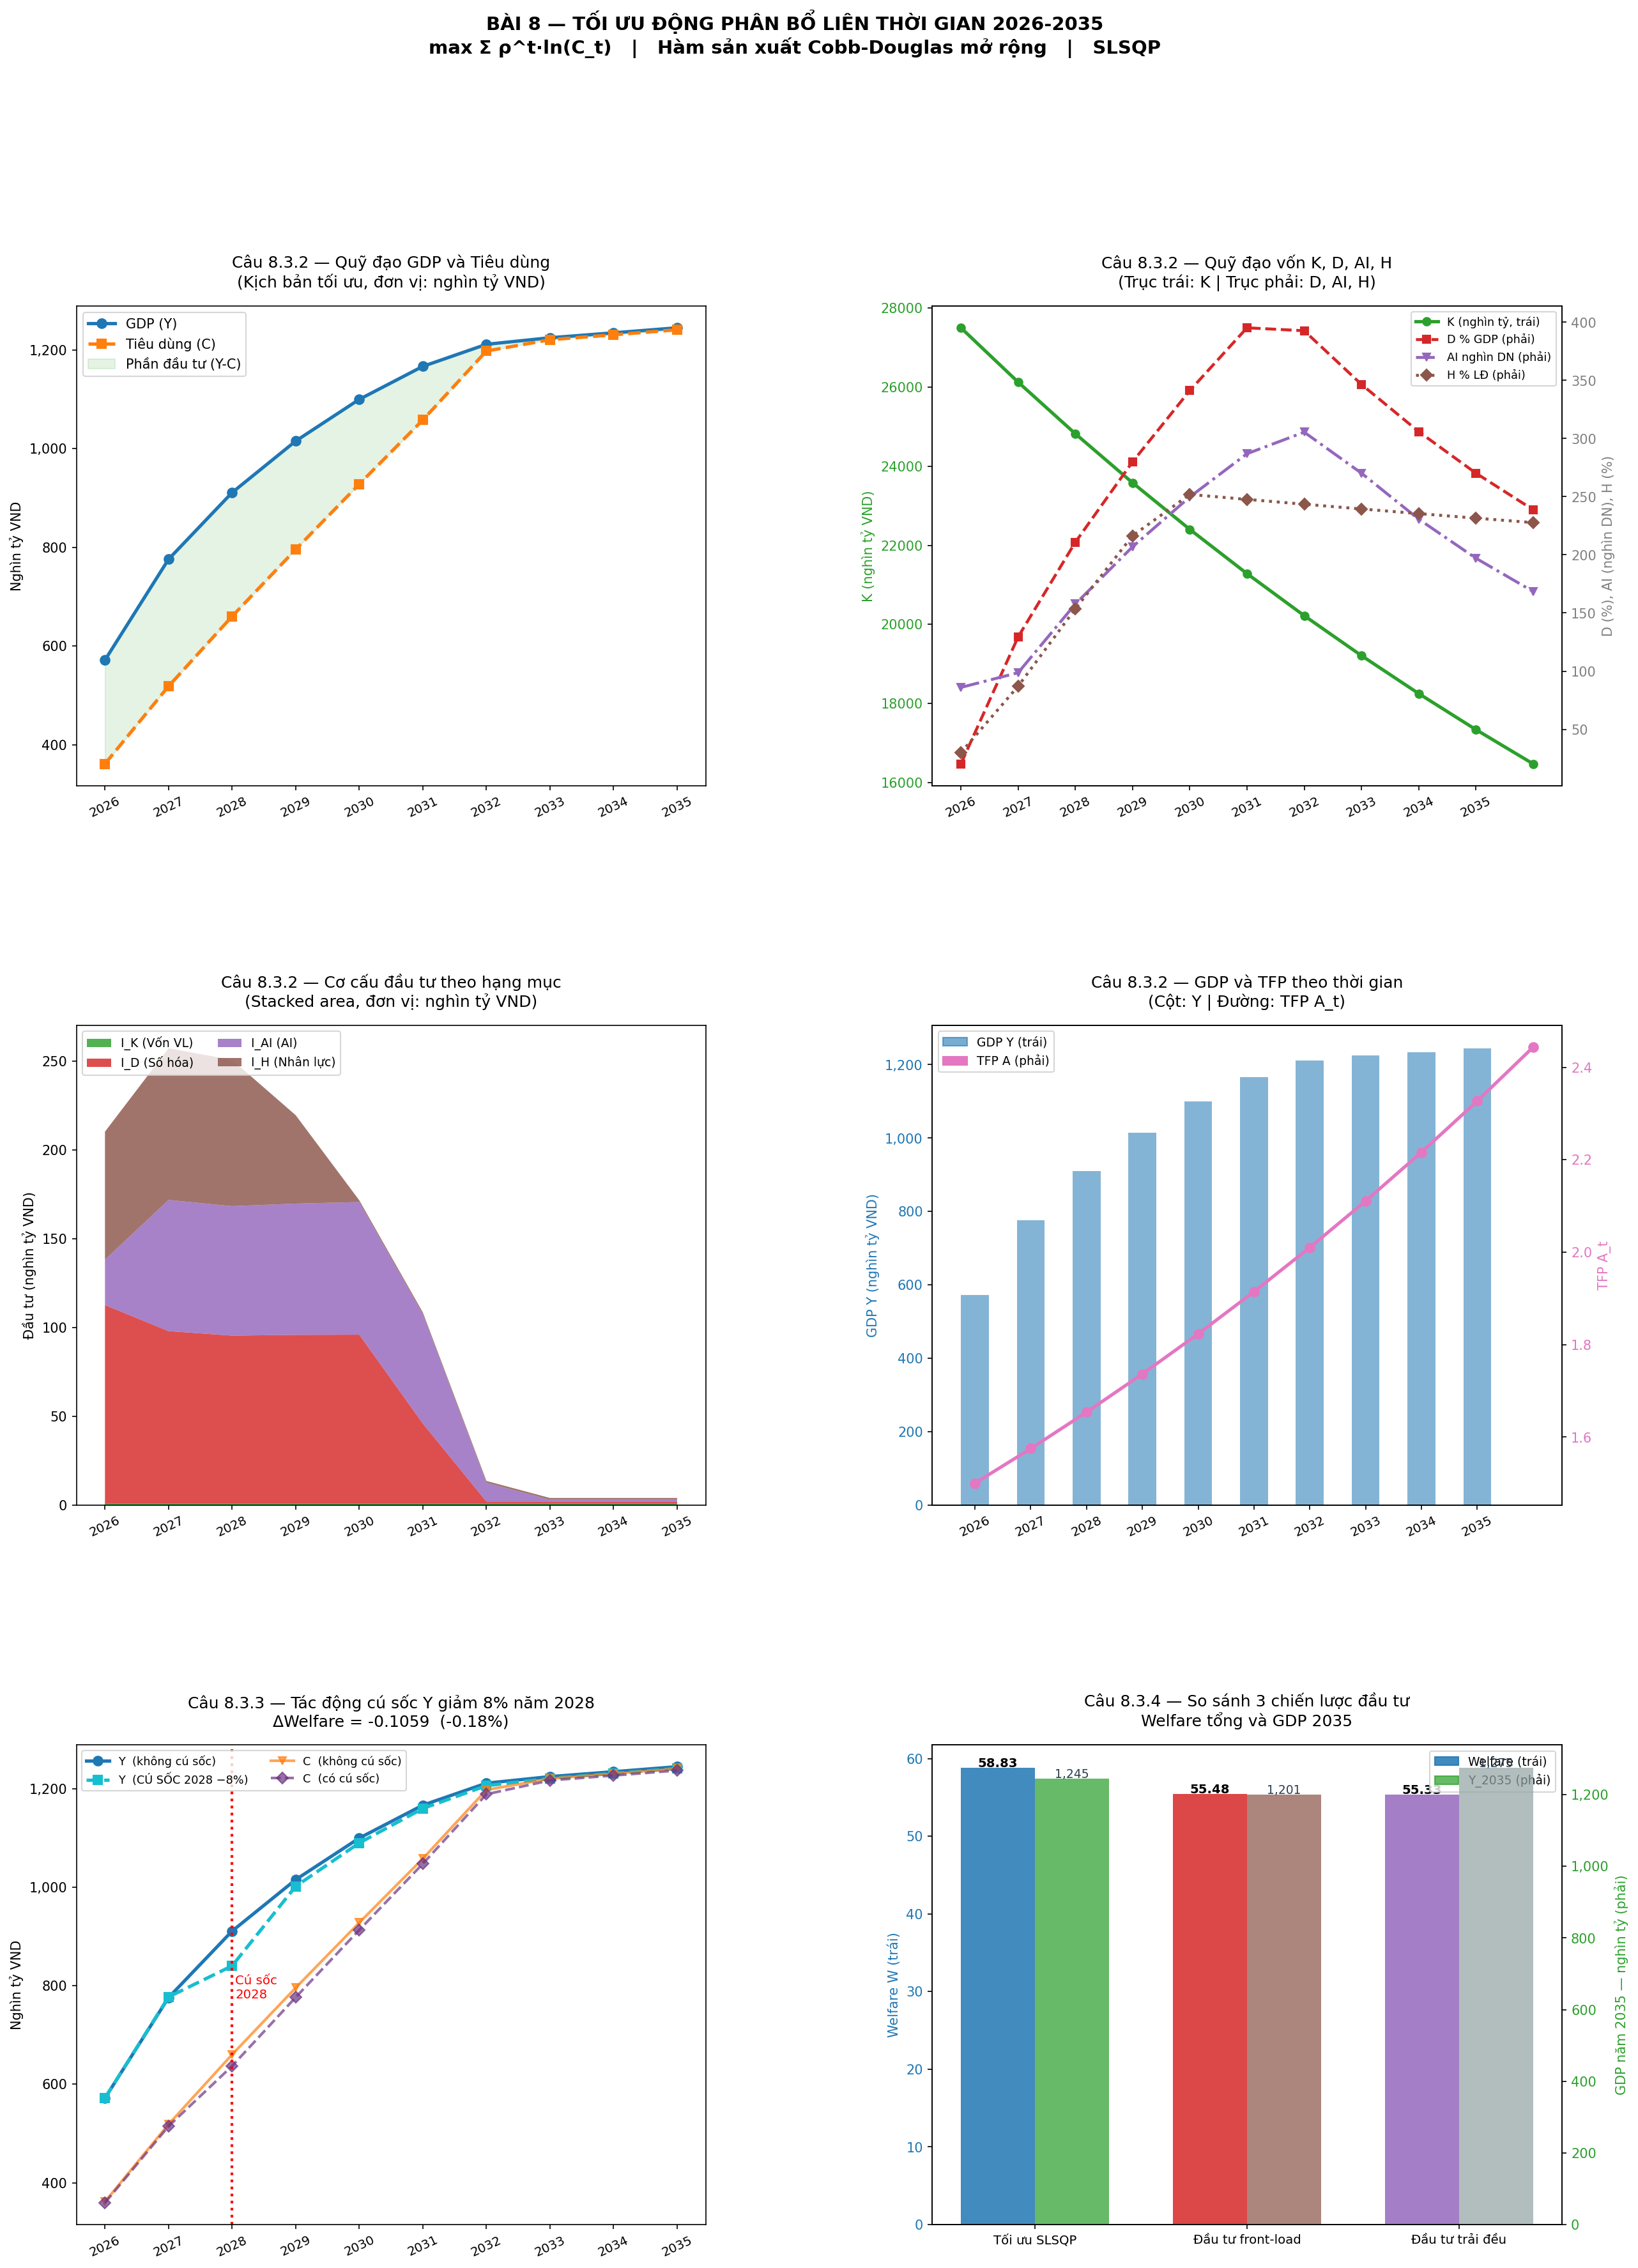

In [8]:
from IPython.display import Image
Image('/mnt/user-data/outputs/bai8_dynamic_chinh.png')